## Formative 1: Time Series Data Pipeline, Task 1 (A–B): EDA & Preprocessing

### Group 1 | MACHINE LEARNING PIPELINE | July 5, 2026

 **Notebook owner**: Singizwa Homere Responsibility: Dataset profiling, missing-value & outlier analysis, analytical questions Q1–Q5 with visualizations and interpretations, including lagged features and moving averages.

Part of a 4-notebook pipeline: 01_eda_preprocessing → 02_modeling → 03_databases → 04_api_and_pipeline. Full end-to-end version: 00_full_pipeline.ipynb. GitHub: https://github.com/Elvin100s/time-series-pipeline.git


# Building a Pipeline for Time Series Data
## Power Consumption of Tétouan City, Morocco

**Dataset:** [Power Consumption of Tetouan City](https://www.kaggle.com/datasets/fedesoriano/electric-power-consumption) — Kaggle / [UCI ML Repository](https://archive.ics.uci.edu/dataset/849/power+consumption+of+tetouan+city)

**Description:** 52,416 observations recorded every 10 minutes across three distribution zones (Quads, Smir, Boussafou) in Tétouan, northern Morocco. Includes weather variables and solar diffuse flow measurements. Full year 2017.

The dataset is loaded programmatically using `kagglehub`, which handles authentication and caching automatically in Google Colab.

**Prediction Target:** Total power consumption (sum of all three zones)

---

### Contents
1. **Task 1** — Time-Series Preprocessing & Exploratory Analysis
2. **Task 2** — Database Design (SQL & MongoDB)
3. **Task 3** — CRUD Endpoints for Time-Series Queries
4. **Task 4** — Prediction / Forecast Script

---
# Task 1: Time-Series Preprocessing and Exploratory Analysis

## 1.1 Setup and Data Loading

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')
sns.set_palette('deep')
print("Libraries loaded.")

Libraries loaded.


In [17]:
!pip install -q kagglehub

import kagglehub
import os, glob

# NOTE: kagglehub needs Kaggle API credentials to download.
# In Colab: Settings (gear icon, left sidebar) -> Secrets -> add KAGGLE_USERNAME and KAGGLE_KEY
#   (get these from kaggle.com/settings -> API -> Create New Token, opens a kaggle.json file
#    containing both values)
# Then uncomment the 3 lines below to load them into the environment:

# from google.colab import userdata
# os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
# os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

try:
    path = kagglehub.dataset_download("fedesoriano/electric-power-consumption")
    print("Downloaded to:", path)
    csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
    print("CSV files found:", csv_files)
    CSV_PATH = csv_files[0]
    print("Using:", CSV_PATH)
except Exception as e:
    print("kagglehub download failed:", e)
    print("Run the fallback cell below instead.")
    CSV_PATH = None

Using Colab cache for faster access to the 'electric-power-consumption' dataset.
Downloaded to: /kaggle/input/electric-power-consumption
CSV files found: ['/kaggle/input/electric-power-consumption/powerconsumption.csv']
Using: /kaggle/input/electric-power-consumption/powerconsumption.csv


In [18]:
# Fallback: if the kagglehub cell above failed (commonly a 403 auth error
# because Kaggle API credentials aren't set in this environment), run this
# cell instead -- it pulls the same dataset from a public GitHub mirror,
# no authentication required.

import os
if 'CSV_PATH' not in dir() or not os.path.exists(CSV_PATH):
    print("Falling back to GitHub mirror (no Kaggle auth needed)...")
    CSV_PATH = 'powerconsumption.csv'
    !wget -q -O {CSV_PATH} "https://raw.githubusercontent.com/sunny2309/datasets/master/Tetuan%20City%20power%20consumption.csv"
    print("Downloaded to:", CSV_PATH)
else:
    print("kagglehub download already succeeded, skipping fallback.")

kagglehub download already succeeded, skipping fallback.


In [19]:
df = pd.read_csv(CSV_PATH)

# Clean column names defensively (strip whitespace, handle BOM)
df.columns = [str(c).strip().replace('\ufeff', '') for c in df.columns]
print("Raw columns:", list(df.columns))

# Find the datetime column regardless of exact name/case
dt_col = next((c for c in df.columns if c.lower() in
               ('datetime', 'date_time', 'date', 'timestamp')), df.columns[0])
print("Detected datetime column:", dt_col)

df[dt_col] = pd.to_datetime(df[dt_col])
df = df.rename(columns={dt_col: 'DateTime'}).set_index('DateTime').sort_index()

# Sanity check: dataset should have exactly 8 remaining feature columns
assert df.shape[1] == 8, "Expected 8 feature columns, got {}: {}".format(df.shape[1], list(df.columns))

df.columns = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows',
              'DiffuseFlows', 'Zone1', 'Zone2', 'Zone3']
df['TotalConsumption'] = df['Zone1'] + df['Zone2'] + df['Zone3']

print("Shape:", df.shape)
print("Range:", df.index.min(), "to", df.index.max())
df.head()

Raw columns: ['Datetime', 'Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows', 'PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']
Detected datetime column: Datetime
Shape: (52416, 9)
Range: 2017-01-01 00:00:00 to 2017-12-30 23:50:00


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,Zone1,Zone2,Zone3,TotalConsumption
DateTime,,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,70425.53544
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,69320.84387
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,67803.22193
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,65489.23209
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,63650.44627


## Part A: Understanding the Dataset
### A.1 Time Range & Frequency

In [20]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print("Time Range:   ", df.index.min(), "->", df.index.max())
print("Duration:     ", (df.index.max() - df.index.min()).days, "days")
print("Records:      ", len(df))
print("Columns:      ", df.shape[1])
print("Granularity:   10-minute intervals (144/day)")

diffs = df.index.to_series().diff().dropna()
print()
print("Most common interval:", diffs.mode()[0])
irregular = diffs[diffs != pd.Timedelta('10min')]
print("Irregular intervals: ", len(irregular),
      "({:.2f}%)".format(len(irregular)/len(diffs)*100))

DATASET OVERVIEW
Time Range:    2017-01-01 00:00:00 -> 2017-12-30 23:50:00
Duration:      363 days
Records:       52416
Columns:       9
Granularity:   10-minute intervals (144/day)

Most common interval: 0 days 00:10:00
Irregular intervals:  0 (0.00%)


### A.2 Missing Values

In [21]:
missing = df.isnull().sum()
print(pd.DataFrame({'Count': missing, '%': (missing/len(df)*100)}).to_string())
print()
if missing.sum() == 0:
    print("No missing values. No imputation needed.")
else:
    df = df.ffill()
    print("Forward-filled missing values.")

                     Count    %
Temperature              0  0.0
Humidity                 0  0.0
WindSpeed                0  0.0
GeneralDiffuseFlows      0  0.0
DiffuseFlows             0  0.0
Zone1                    0  0.0
Zone2                    0  0.0
Zone3                    0  0.0
TotalConsumption         0  0.0

No missing values. No imputation needed.


### A.3 Data Types & Duplicates

In [22]:
print(df.dtypes.to_string())
print()
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate timestamps:", df.index.duplicated().sum())

Temperature            float64
Humidity               float64
WindSpeed              float64
GeneralDiffuseFlows    float64
DiffuseFlows           float64
Zone1                  float64
Zone2                  float64
Zone3                  float64
TotalConsumption       float64

Duplicate rows: 0
Duplicate timestamps: 0


### A.4 Statistical Distributions

In [23]:
desc = df.describe().T
desc['skew'] = df.skew()
desc['kurtosis'] = df.kurtosis()
desc[['mean','std','min','25%','50%','75%','max','skew','kurtosis']]

,mean,std,min,25%,50%,75%,max,skew,kurtosis
Temperature,18.810024,5.815476,3.247000,14.410000,18.780000,22.890000,40.01000,0.196719,-0.303321
Humidity,68.259518,15.551177,11.340000,58.310000,69.860000,81.400000,94.80000,-0.625166,-0.121860
WindSpeed,1.959489,2.348862,0.050000,0.078000,0.086000,4.915000,6.48300,0.462423,-1.783169
GeneralDiffuseFlows,182.696614,264.400960,0.004000,0.062000,5.035500,319.600000,1163.00000,1.306973,0.402768
DiffuseFlows,75.028022,124.210949,0.011000,0.122000,4.456000,101.000000,936.00000,2.456907,7.002902
Zone1,32344.970564,7130.562564,13895.696200,26310.668692,32265.920340,37309.018185,52204.39512,0.228864,-0.754054
Zone2,21042.509082,5201.465892,8560.081466,16980.766032,20823.168405,24713.717520,37408.86076,0.328876,-0.437397
Zone3,17835.406218,6622.165099,5935.174070,13129.326630,16415.117470,21624.100420,47598.32636,1.023871,1.086393
TotalConsumption,71222.885864,17143.138964,36785.039739,56499.074640,69788.790940,83749.172310,134208.14595,0.518854,-0.232507


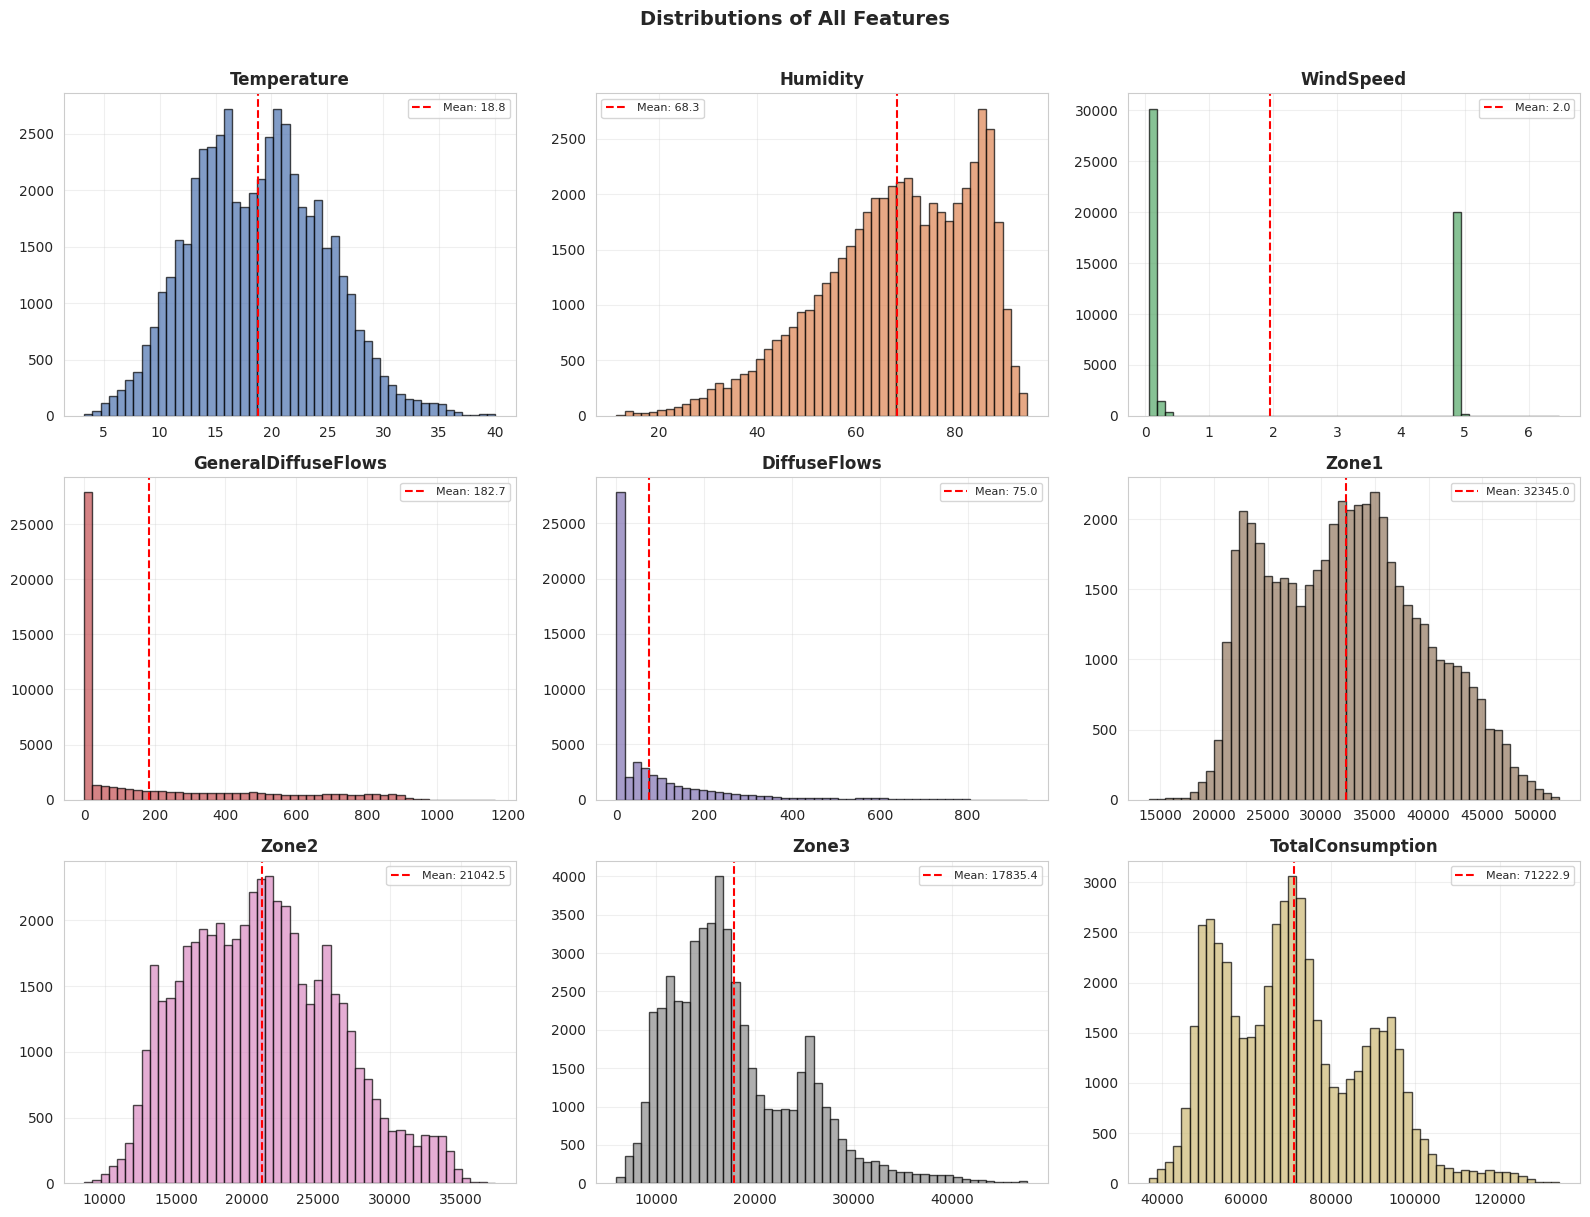

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for i, col in enumerate(df.columns):
    ax = axes.flat[i]
    ax.hist(df[col], bins=50, edgecolor='black', alpha=0.7,
            color=sns.color_palette()[i % 10])
    ax.set_title(col, fontweight='bold')
    m = df[col].mean()
    ax.axvline(m, color='red', ls='--', lw=1.5, label='Mean: {:.1f}'.format(m))
    ax.legend(fontsize=8)
plt.suptitle('Distributions of All Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

**Interpretation:**
- **Temperature** ≈ normal around 19 °C (Mediterranean climate).
- **Humidity** left-skewed (>55 % most of the time — coastal).
- **Wind Speed** & **Diffuse Flows** strongly right-skewed (night zeros + daytime peaks).
- **Zone 1** has the highest consumption; **Zone 3** shows a bimodal pattern.

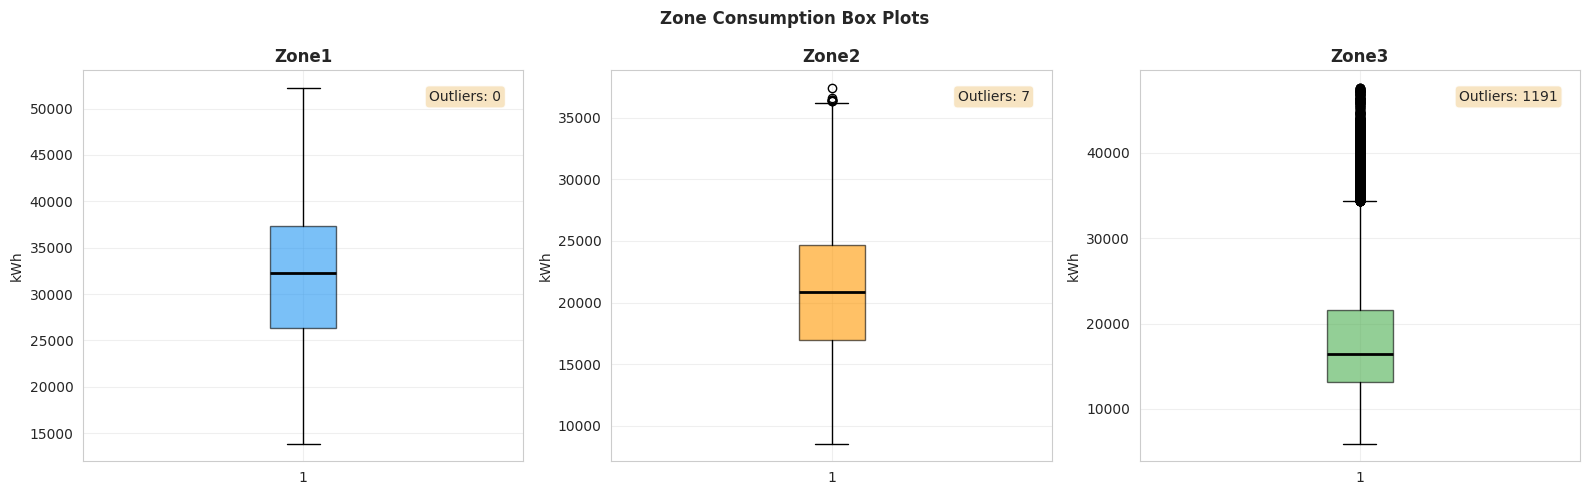

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (col, color) in enumerate(zip(['Zone1','Zone2','Zone3'],
                                      ['#2196F3','#FF9800','#4CAF50'])):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='black', lw=2))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('kWh')
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    axes[i].text(0.95, 0.95, 'Outliers: {}'.format(n_out),
                 transform=axes[i].transAxes, ha='right', va='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.suptitle('Zone Consumption Box Plots', fontweight='bold')
plt.tight_layout(); plt.show()

**Outlier Decision:** These are genuine peak-demand events (heat waves, industrial spikes), not measurement errors. Retaining them preserves the model's ability to predict extreme demand.

---
## Part B: Analytical Questions

Five questions; at least two use lagged features / moving averages.

### Q1 — Seasonal Trend

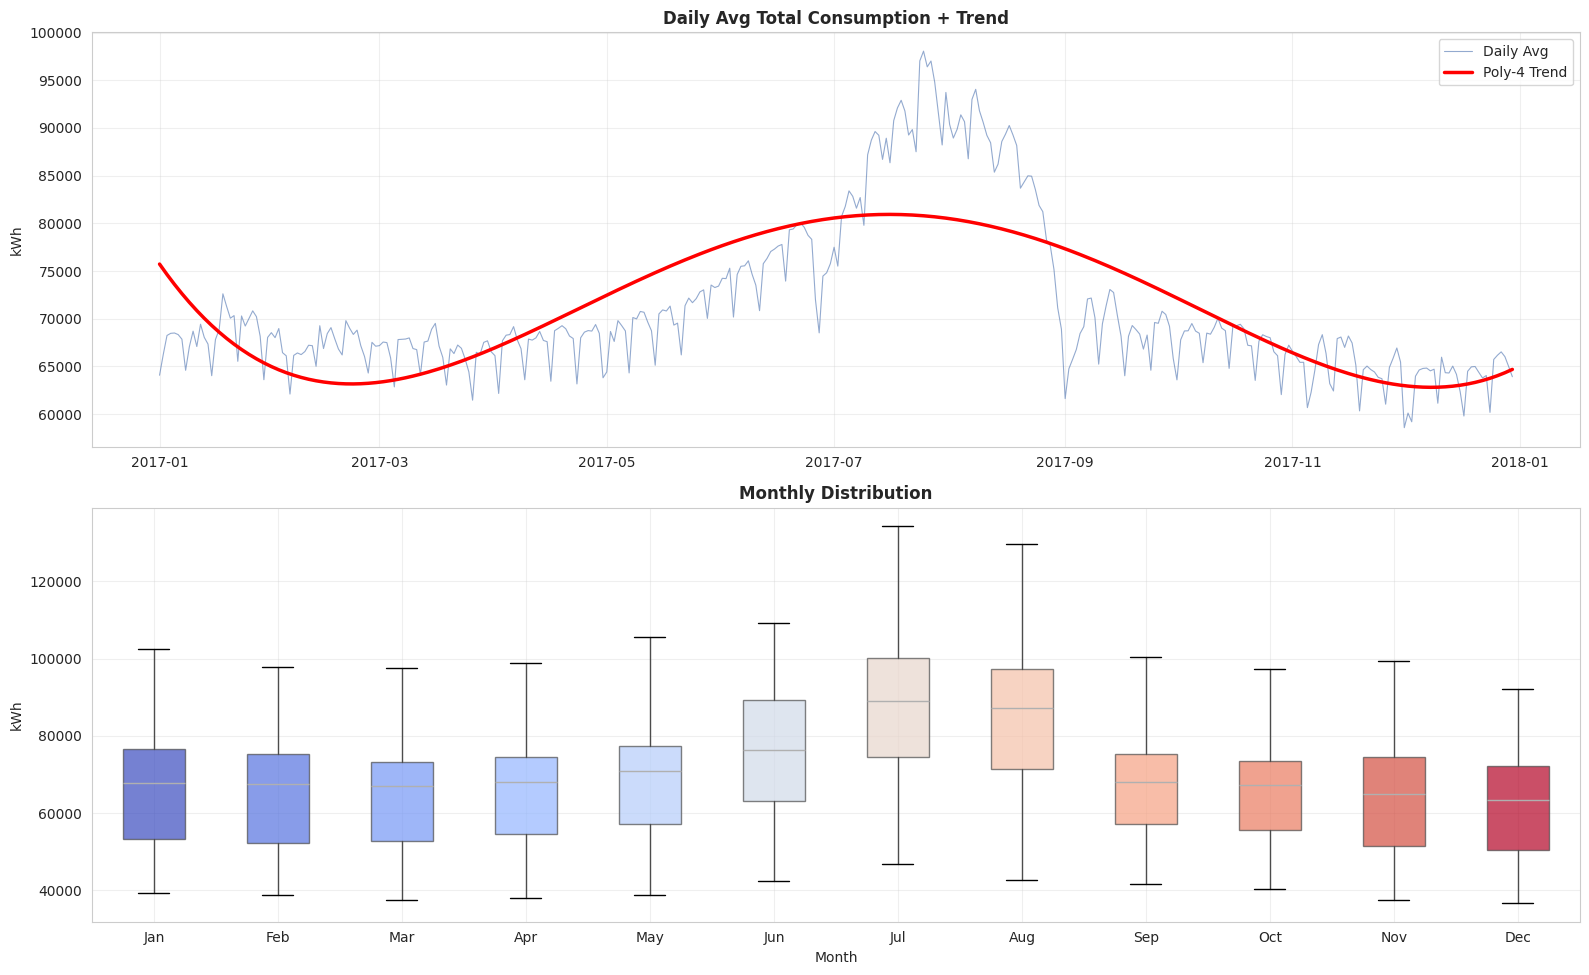

In [26]:
daily = df.resample('D').mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ax = axes[0]
ax.plot(daily.index, daily['TotalConsumption'], alpha=0.6, lw=0.8, label='Daily Avg')
x = np.arange(len(daily))
p = np.poly1d(np.polyfit(x, daily['TotalConsumption'].values, 4))
ax.plot(daily.index, p(x), color='red', lw=2.5, label='Poly-4 Trend')
ax.set_title('Daily Avg Total Consumption + Trend', fontweight='bold')
ax.set_ylabel('kWh'); ax.legend()

monthly = df.copy(); monthly['Month'] = monthly.index.month
mn = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax2 = axes[1]
bp = monthly.boxplot(column='TotalConsumption', by='Month', ax=ax2,
                      patch_artist=True, return_type='dict')
for patch, c in zip(bp['TotalConsumption']['boxes'],
                     plt.cm.coolwarm(np.linspace(0,1,12))):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax2.set_xticklabels(mn)
ax2.set_title('Monthly Distribution', fontweight='bold')
ax2.set_ylabel('kWh'); ax2.set_xlabel('Month')
fig.suptitle('')
plt.tight_layout(); plt.show()

**Interpretation:** Clear U-shaped seasonal pattern — spring trough (Mar-Apr), summer peak (Jul-Aug) from AC usage, minor winter rise from heating.

### Q2 — Weather Correlation

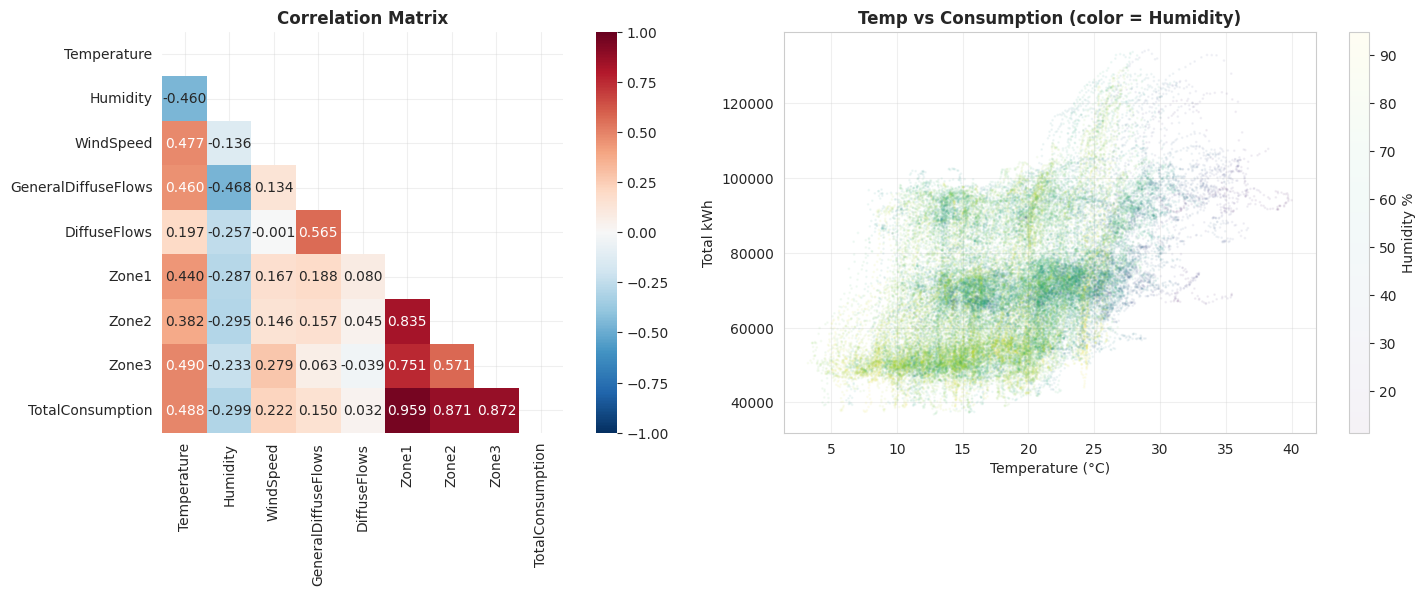

Correlations with TotalConsumption:
Zone1                  0.959146
Zone3                  0.871777
Zone2                  0.871069
Temperature            0.488238
WindSpeed              0.221706
GeneralDiffuseFlows    0.150368
DiffuseFlows           0.032068
Humidity              -0.299059
Name: TotalConsumption, dtype: float64


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, ax=axes[0], square=True, vmin=-1, vmax=1)
axes[0].set_title('Correlation Matrix', fontweight='bold')

sc = axes[1].scatter(df['Temperature'], df['TotalConsumption'],
                     alpha=0.05, s=1, c=df['Humidity'], cmap='viridis')
axes[1].set_xlabel('Temperature (°C)'); axes[1].set_ylabel('Total kWh')
axes[1].set_title('Temp vs Consumption (color = Humidity)', fontweight='bold')
plt.colorbar(sc, ax=axes[1], label='Humidity %')
plt.tight_layout(); plt.show()

print("Correlations with TotalConsumption:")
print(corr['TotalConsumption'].drop('TotalConsumption').sort_values(ascending=False))

**Interpretation:** Temperature has moderate positive correlation (~0.44) — consumption rises sharply above 25 °C (nonlinear, AC-driven). Humidity is negatively correlated. The three zones correlate strongly with each other (>0.58).

### Q3 (Lagged Features) — Autocorrelation of Daily Consumption

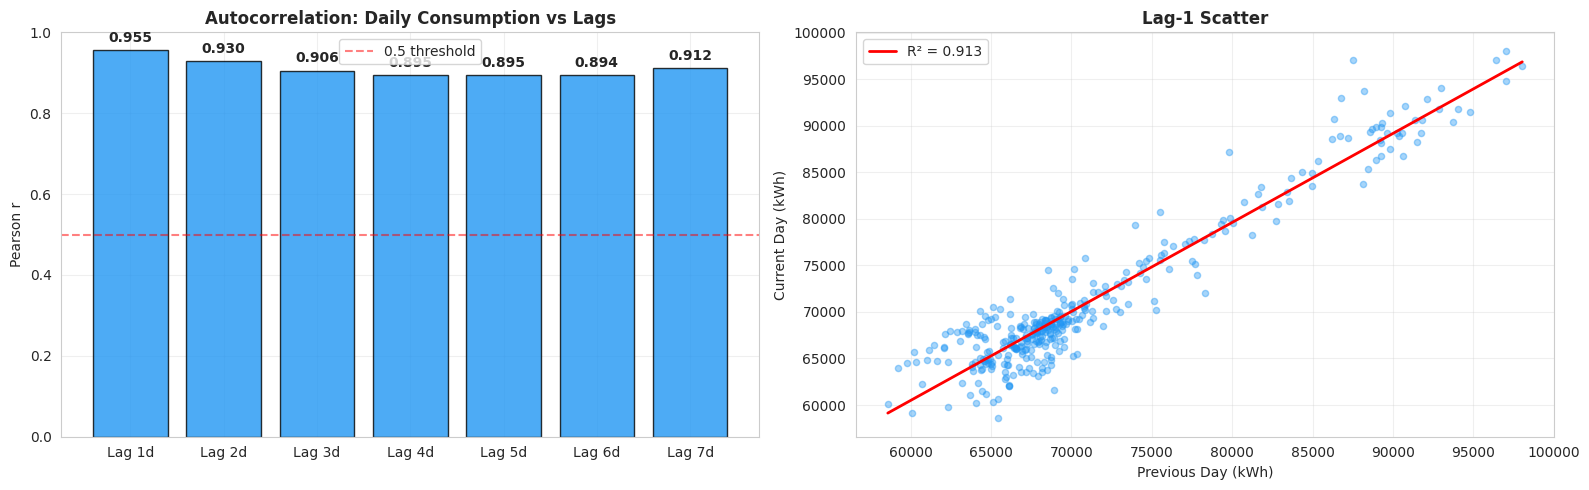

In [28]:
daily_tc = df['TotalConsumption'].resample('D').mean()
lag_corrs = {i: daily_tc.corr(daily_tc.shift(i)) for i in range(1, 8)}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

labels = ['Lag {}d'.format(i) for i in range(1, 8)]
vals = list(lag_corrs.values())
colors = ['#2196F3' if v > 0.5 else '#FF9800' if v > 0.3 else '#9E9E9E'
          for v in vals]
axes[0].bar(labels, vals, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylim(0, 1)
axes[0].set_title('Autocorrelation: Daily Consumption vs Lags', fontweight='bold')
axes[0].set_ylabel('Pearson r')
axes[0].axhline(0.5, color='red', ls='--', alpha=0.5, label='0.5 threshold')
axes[0].legend()
for i, v in enumerate(vals):
    axes[0].text(i, v+0.02, '{:.3f}'.format(v), ha='center', fontweight='bold')

axes[1].scatter(daily_tc.shift(1), daily_tc, alpha=0.4, s=20, color='#2196F3')
axes[1].set_xlabel('Previous Day (kWh)'); axes[1].set_ylabel('Current Day (kWh)')
axes[1].set_title('Lag-1 Scatter', fontweight='bold')
ok = ~(daily_tc.shift(1).isna() | daily_tc.isna())
sl, ic, r, _, _ = stats.linregress(daily_tc.shift(1)[ok], daily_tc[ok])
xr = np.linspace(daily_tc.min(), daily_tc.max(), 100)
axes[1].plot(xr, sl*xr+ic, color='red', lw=2, label='R² = {:.3f}'.format(r**2))
axes[1].legend()
plt.tight_layout(); plt.show()

**Interpretation:** Lag-1 has the strongest autocorrelation — weather patterns persist day-to-day. Correlations decay through lag-7, hinting at weekly cycles. Including lag features will boost forecasting accuracy.

### Q4 (Moving Averages) — Trend Decomposition via Rolling Windows

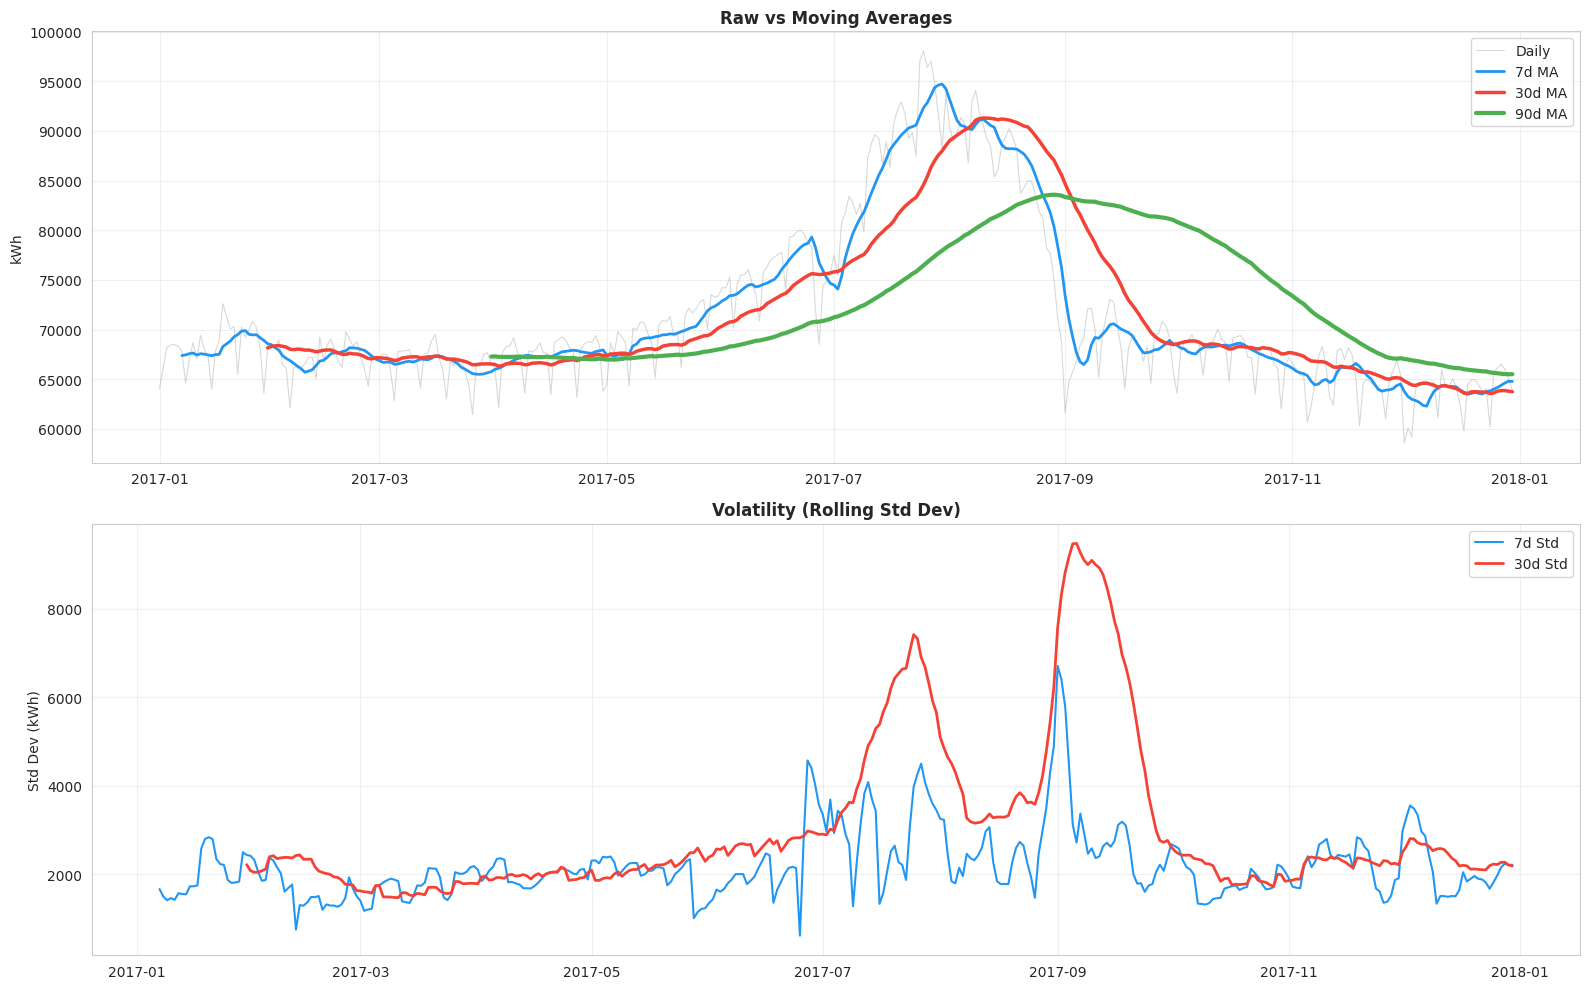

In [29]:
daily_tc = df['TotalConsumption'].resample('D').mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(daily_tc.index, daily_tc, alpha=0.3, lw=0.8, color='gray', label='Daily')
axes[0].plot(daily_tc.index, daily_tc.rolling(7).mean(), lw=2, color='#2196F3', label='7d MA')
axes[0].plot(daily_tc.index, daily_tc.rolling(30).mean(), lw=2.5, color='#F44336', label='30d MA')
axes[0].plot(daily_tc.index, daily_tc.rolling(90).mean(), lw=3, color='#4CAF50', label='90d MA')
axes[0].set_title('Raw vs Moving Averages', fontweight='bold')
axes[0].set_ylabel('kWh'); axes[0].legend()

axes[1].plot(daily_tc.index, daily_tc.rolling(7).std(), lw=1.5, color='#2196F3', label='7d Std')
axes[1].plot(daily_tc.index, daily_tc.rolling(30).std(), lw=2, color='#F44336', label='30d Std')
axes[1].set_title('Volatility (Rolling Std Dev)', fontweight='bold')
axes[1].set_ylabel('Std Dev (kWh)'); axes[1].legend()
plt.tight_layout(); plt.show()

**Interpretation:** The 30-day MA reveals the seasonal arc clearly — spring trough to summer peak (~40-50 % higher). Volatility spikes in summer from weather-sensitive AC loads. Both 7-day and 30-day MAs are valuable model features.

### Q5 — Hourly & Day-of-Week Patterns

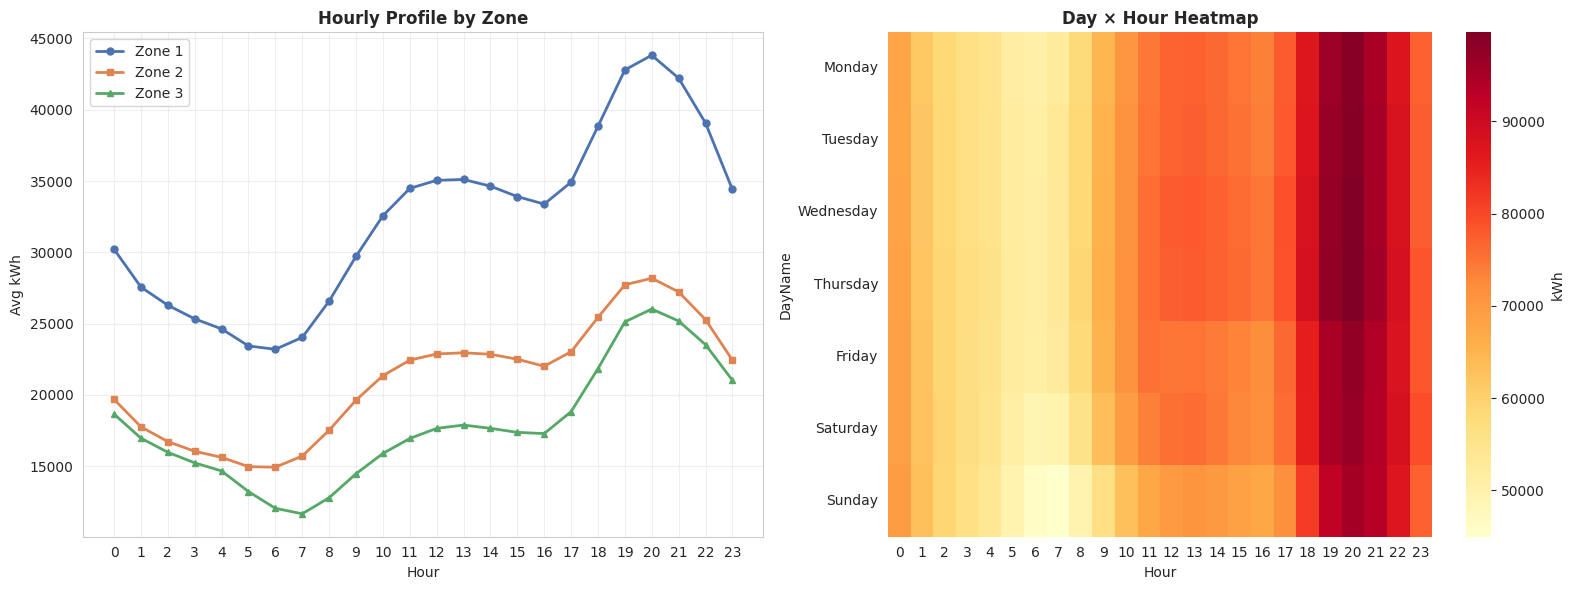

Peak hour:     20:00 — 98,037 kWh
Off-peak hour: 6:00 — 50,190 kWh
Ratio: 1.95x


In [30]:
tmp = df.copy()
tmp['Hour'] = tmp.index.hour
tmp['DayName'] = tmp.index.day_name()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ha = tmp.groupby('Hour')[['Zone1','Zone2','Zone3']].mean()
axes[0].plot(ha.index, ha['Zone1'], 'o-', label='Zone 1', lw=2, ms=5)
axes[0].plot(ha.index, ha['Zone2'], 's-', label='Zone 2', lw=2, ms=5)
axes[0].plot(ha.index, ha['Zone3'], '^-', label='Zone 3', lw=2, ms=5)
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Avg kWh')
axes[0].set_title('Hourly Profile by Zone', fontweight='bold')
axes[0].set_xticks(range(24)); axes[0].legend()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pv = tmp.groupby(['DayName','Hour'])['TotalConsumption'].mean().reset_index()
pt = pv.pivot(index='DayName', columns='Hour', values='TotalConsumption').reindex(day_order)
sns.heatmap(pt, cmap='YlOrRd', ax=axes[1], cbar_kws={'label':'kWh'})
axes[1].set_title('Day × Hour Heatmap', fontweight='bold')
plt.tight_layout(); plt.show()

th = ha.sum(axis=1)
print("Peak hour:     {}:00 — {:,.0f} kWh".format(th.idxmax(), th.max()))
print("Off-peak hour: {}:00 — {:,.0f} kWh".format(th.idxmin(), th.min()))
print("Ratio: {:.2f}x".format(th.max() / th.min()))

**Interpretation:** All zones peak around noon and dip at night. Weekday consumption exceeds weekends (commercial loads). Zone 1 carries ~50 % more than Zone 2.